In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the dataset for the AND gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])  # AND gate output

def plot_dataset(X, Y, plt_already=False, title='Dataset in $\\mathbb{R}^2$'):
  if not plt_already:
    # Create the plot
    plt.figure(figsize=(8, 6))

  # Plot the data points with different markers for different classes
  for i in range(len(X)):
      if Y[i] == 0:
          plt.scatter(X[i, 0], X[i, 1], color='red', marker='x', s=100, label='Class 0' if i == 0 else "")
      else:
          plt.scatter(X[i, 0], X[i, 1], color='blue', marker='x', s=100, label='Class 1' if i == 3 else "")

  # Add labels and title
  plt.xlabel('$x_1$', fontsize=14)
  plt.ylabel('$x_2$', fontsize=14)
  plt.title(title, fontsize=16)

  # Set the axes limits
  plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
  plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

  # Add grid
  plt.grid(True)

  # Add a legend
  plt.legend(loc='upper left', fontsize=12)

  # Show the plot
  plt.show()

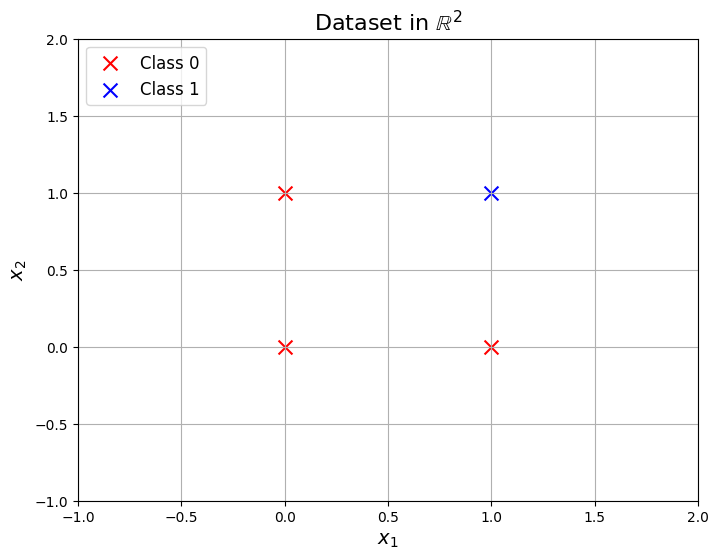

In [2]:
plot_dataset(X, Y)

In [3]:
w = np.random.rand(2) * 2 - 1
b = np.random.rand() * 2 - 1

print(w)
print(b)

[-0.05407606  0.10736106]
0.46916200082050175


In [4]:
w = [0.892, 0.626]
b = -0.396

In [5]:
def plot_dataset_and_decision_boundary(X, Y, w, b, title):
    # Create a meshgrid for plotting the decision boundary
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.01),
                           np.arange(x2_min, x2_max, 0.01))

    # Calculate the decision boundary
    Z = w[0] * xx1 + w[1] * xx2 + b
    Z = 1 / (1 + np.exp(-Z))  # Sigmoid activation function
    Z = np.round(Z)  # Round to get binary output
    Z = Z.reshape(xx1.shape)

    # Create the plot
    plt.figure(figsize=(8, 6))

    # Plot the decision boundary
    plt.contourf(xx1, xx2, -Z, alpha=0.2, cmap=plt.cm.Paired)

    plot_dataset(X, Y, plt_already=True, title=title)

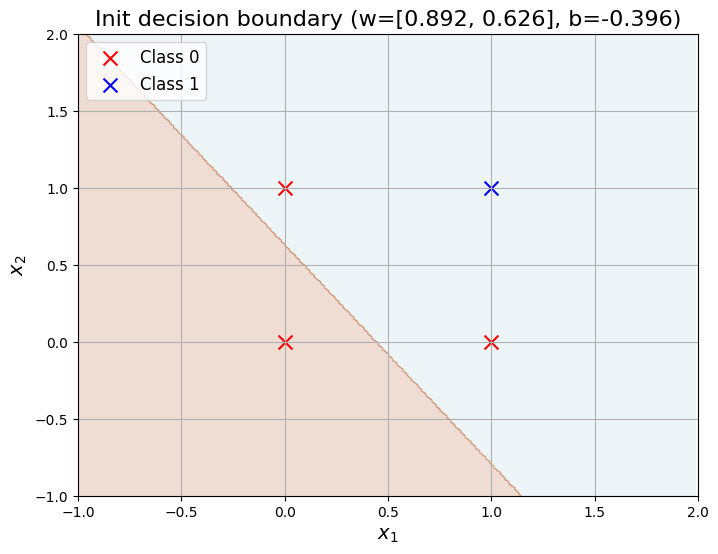

In [6]:
plot_dataset_and_decision_boundary(X, Y, w, b, title='Init decision boundary (w=[{:.3f}, {:.3f}], b={:.3f})'.format(w[0], w[1], b))

In [7]:
affine = lambda x, w, b: np.dot(w, x) + b
activation = lambda x: 1 / (1 + np.exp(-x))
alpha = 0.2
epsilon = 0.00001

Iteration 1: x=[0 0], y=0, wt=[0.892, 0.626], bt=-0.396
z=-0.396
y_hat=0.4022737611102629
error=-0.4022737611102629
Iteration 1: weights=[0.892 0.626], bias=-0.4764547522220526


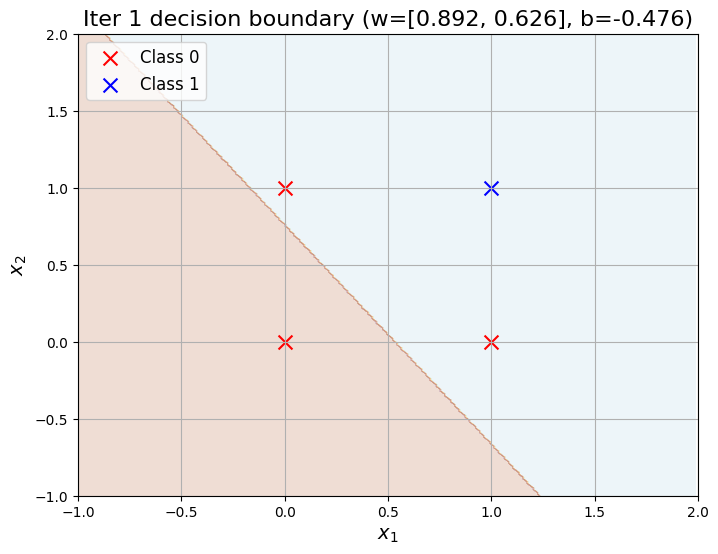

Iteration 2: x=[0 1], y=0, wt=[0.892 0.626], bt=-0.4764547522220526
z=0.14954524777794742
y_hat=0.5373167924707036
error=-0.5373167924707036
Iteration 2: weights=[0.892      0.51853664], bias=-0.5839181107161933


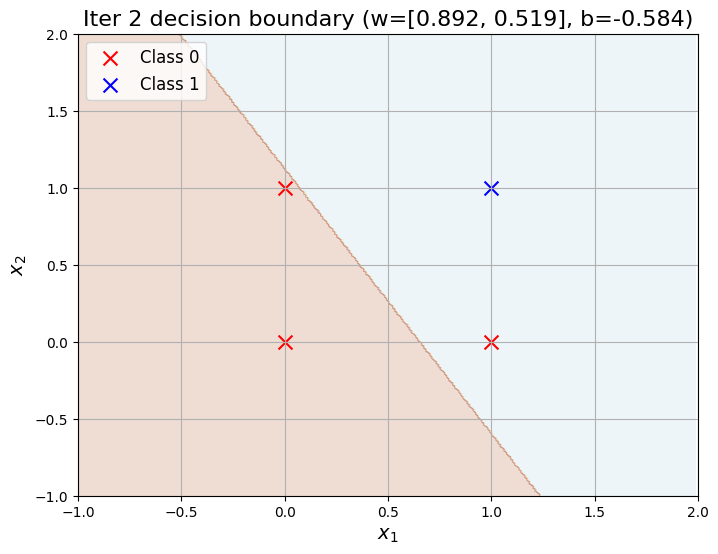

Iteration 3: x=[1 0], y=0, wt=[0.892      0.51853664], bt=-0.5839181107161933
z=0.30808188928380675
y_hat=0.576417003151562
error=-0.576417003151562
Iteration 3: weights=[0.7767166  0.51853664], bias=-0.6992015113465057


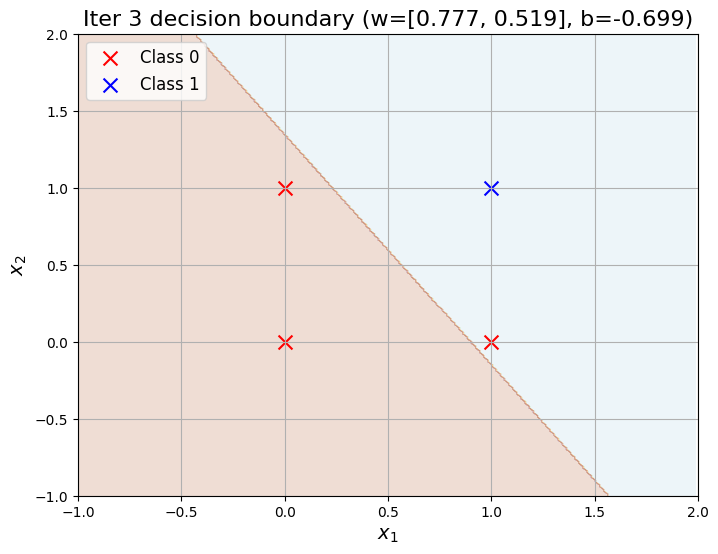

Iteration 4: x=[1 1], y=1, wt=[0.7767166  0.51853664], bt=-0.6992015113465057
z=0.5960517295290412
y_hat=0.6447524855604339
error=0.35524751443956615
Iteration 4: weights=[0.8477661  0.58958614], bias=-0.6281520084585924


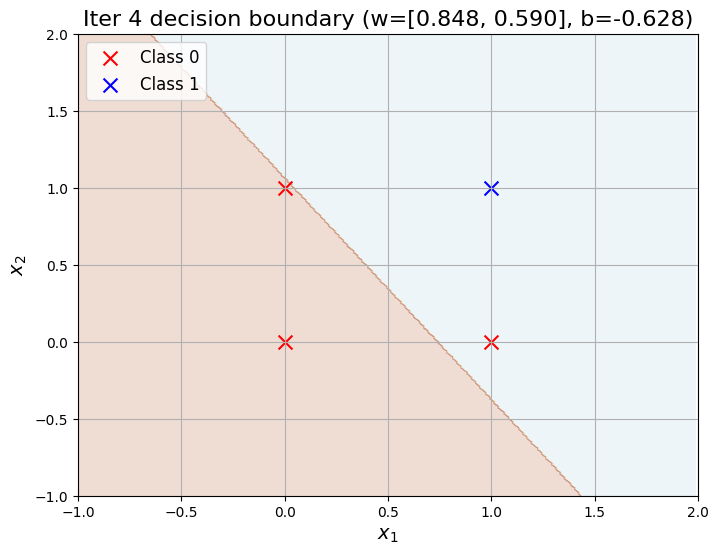

Iteration 5: x=[0 0], y=0, wt=[0.8477661  0.58958614], bt=-0.6281520084585924
z=-0.6281520084585924
y_hat=0.3479296822739264
error=-0.3479296822739264
Iteration 5: weights=[0.8477661  0.58958614], bias=-0.6977379449133777


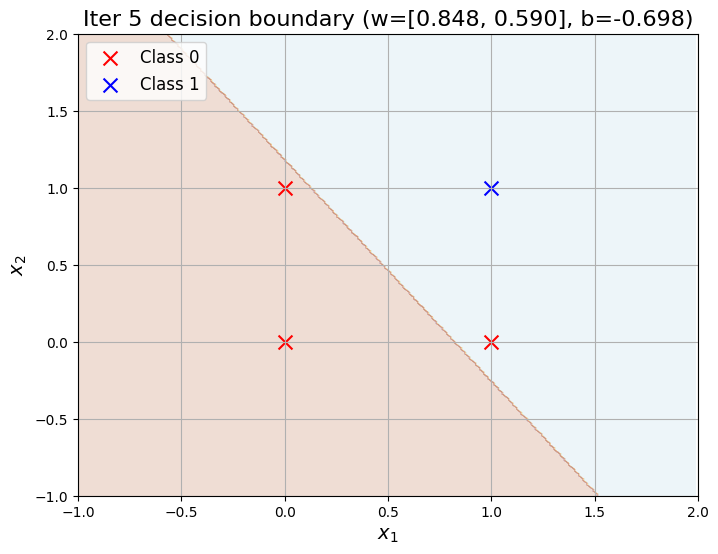

Iteration 6: x=[0 1], y=0, wt=[0.8477661  0.58958614], bt=-0.6977379449133777
z=-0.10815180051960527
y_hat=0.4729883738980015
error=-0.4729883738980015
Iteration 6: weights=[0.8477661  0.49498847], bias=-0.792335619692978


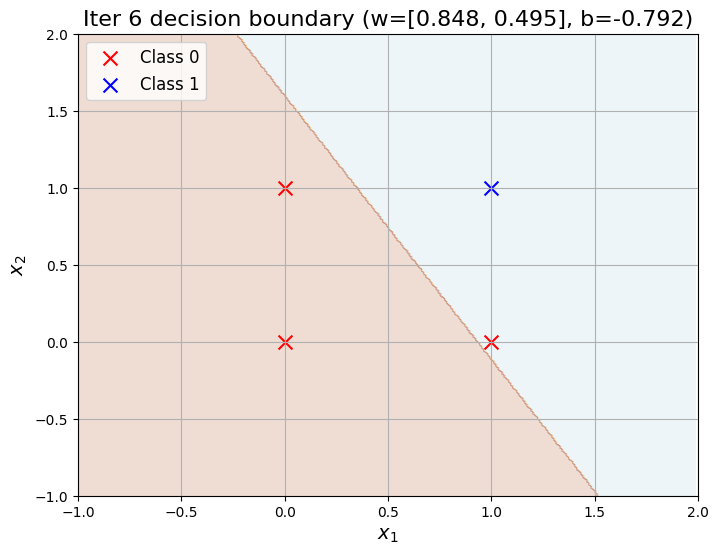

Iteration 7: x=[1 0], y=0, wt=[0.8477661  0.49498847], bt=-0.792335619692978
z=0.055430482564622796
y_hat=0.5138540735583802
error=-0.5138540735583802
Iteration 7: weights=[0.74499529 0.49498847], bias=-0.8951064344046541


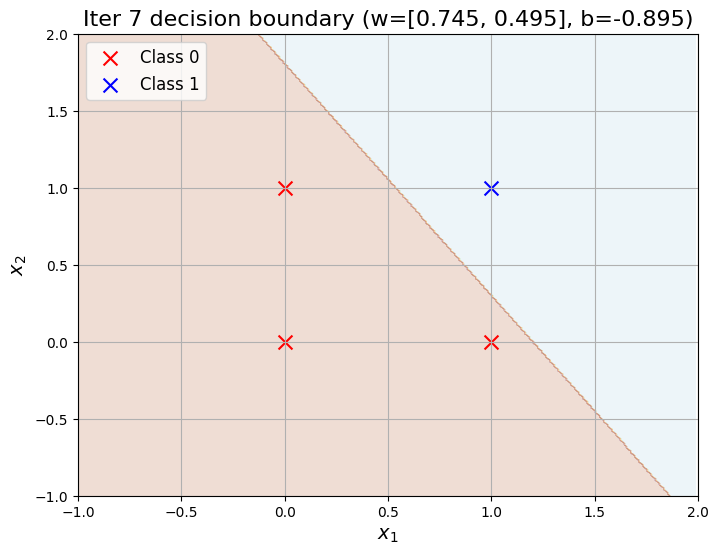

Iteration 8: x=[1 1], y=1, wt=[0.74499529 0.49498847], bt=-0.8951064344046541
z=0.3448773227554428
y_hat=0.5853747943069202
error=0.4146252056930798
Iteration 8: weights=[0.82792033 0.57791351], bias=-0.8121813932660381


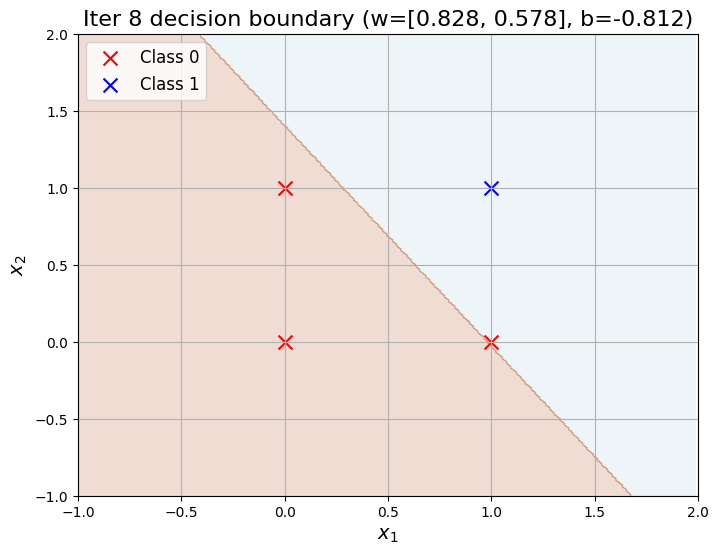

In [8]:
wt = w.copy()
bt = b
data_pairs = list(zip(X, Y))

i = 0
for _ in range(8):
  x, y = data_pairs[i % 4]

  print('Iteration ' + str(i+1) + ': x=' + str(x) + ', y=' + str(y) + ', wt=' + str(wt) + ', bt=' + str(bt))

  # Calculate neuron activation
  z = affine(x, wt, bt)
  print('z=' + str(z))
  y_hat = activation(z)
  print('y_hat=' + str(y_hat))

  # Calculate the error
  error = y - y_hat
  print('error=' + str(error))

  # Update weights and bias
  wt += alpha * error * x
  bt += alpha * error

  print('Iteration ' + str(i+1) + ': weights=' + str(wt) + ', bias=' + str(bt))
  plot_dataset_and_decision_boundary(X, Y, wt, bt, title='Iter '+str(i+1)+' decision boundary (w=[{:.3f}, {:.3f}], b={:.3f})'.format(wt[0], wt[1], bt))

  i += 1

## Interactive Controls\nUse the widget panel below to explore parameters live inside JupyterLite.\n

In [ ]:
# INTERACTIVE_WIDGET_SECTION\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport ipywidgets as widgets\n\ndef _interactive_demo(freq=1.0, amp=1.0, phase=0.0):\n    x=np.linspace(-10,10,500)\n    y=amp*np.sin(freq*x+phase)\n    plt.figure(figsize=(8,4))\n    plt.plot(x,y,lw=2)\n    plt.grid(True)\n    plt.title('Interactive Demo Panel')\n    plt.show()\n\nwidgets.interact(_interactive_demo,\n    freq=widgets.FloatSlider(value=1.0,min=0.1,max=5.0,step=0.1),\n    amp=widgets.FloatSlider(value=1.0,min=0.1,max=3.0,step=0.1),\n    phase=widgets.FloatSlider(value=0.0,min=-3.14,max=3.14,step=0.1))\n